In [498]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


# Normal Distribution

<Axes: ylabel='Count'>

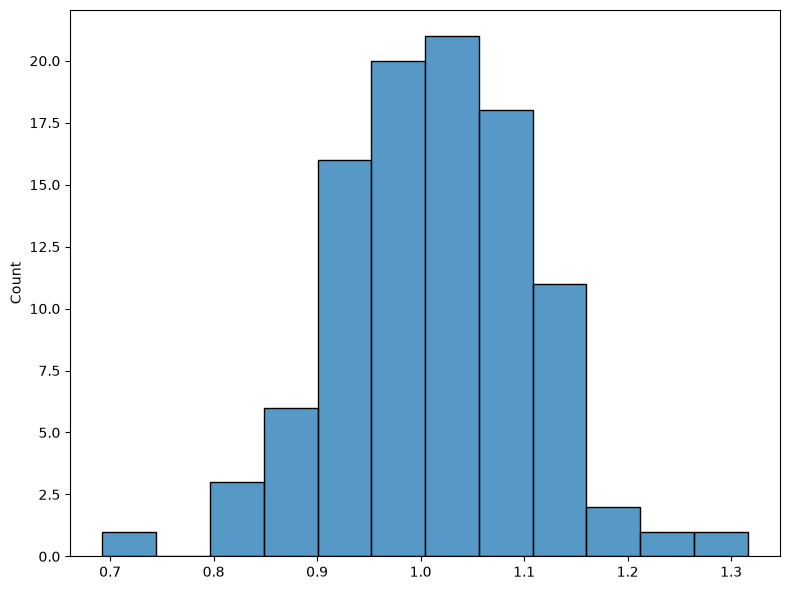

In [499]:
# create a normal distribution
mu, sigma_ = 1, 0.1 # mean and standard deviation
normal_data = np.random.normal(mu,sigma_,100)

plt.figure(
    figsize=(8,6),
    layout = 'tight'
)

sns.histplot(
    data=normal_data
)

In [500]:
def log_likelihood_calculation(x:np.array, mu:float, sigma:float, n_samples:int):
    """ 
    outputs a list of the loglihood and their derivitives
    
    """
    # loop through the samples at the given mu and sigma
    exponential = np.exp(
        -(np.sum((x - mu)**2)) / (2 * sigma**2)
        )
    fraction = (
        1 / np.sqrt(2 * np.pi * sigma**2)
        ) ** n_samples

    likelihood = fraction * exponential
    log_likelihood = np.log(likelihood)

    # calculate the derivitives
    mu_prime = 1/sigma**2 * (np.sum(x) - n_samples * mu)

    sigma_prime = (- n_samples / sigma) + (1/sigma**3 * np.sum((x - mu) ** 2))



    return mu_prime, sigma_prime, log_likelihood

def viz_the_history(history:list):
    """
    Show how the function got to its solution
    """
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(
        3,1,figsize=(10,8)
    )
    # the y labels
    labels = ['Log-Likelihood','Mean','Sigma']

    # loop and visualise!
    for i in range(3):
        sns.lineplot(
            data=df.iloc[:100],
            x='Iteration',
            y=labels[i],
            ax=axes[i]
        )
    
    # add title
    plt.suptitle(
        "A Visual Representation of MLE",
        fontsize=18,
        fontweight='bold',
        color='grey'
    )

    # adjust the axis labels
    size_and_color = {
        "fontsize":12,
        "fontweight":"bold",
        "color":"grey"
    }

    for ax in axes.flat:
        ax.set_ylabel(ax.get_ylabel(),**size_and_color)
        ax.set_xlabel(ax.get_xlabel(),**size_and_color)

    plt.tight_layout()

def gaussian_maximum_likelihood_function(x : np.array):
    """
    Manually computes the MLE parameters for a Gaussian distribution
    using gradient ascent on the log-likelihood.

    Steps:
    1. Initialise mu and sigma.
    2. Calculate the Gaussian log-likelihood.
    3. Calculate the gradients with respect to mu and sigma.
    4. Update mu and sigma using gradient ascent.
    5. Repeat until convergence.
    6. Visualise the optimisation history.
    """
    # set mu to the first point in the data
    # as we will be changing these over iterations
    # what they begin with does not matter.
    mu = np.min(x)
    sigma = 1
    n_samples = len(x)

    # create likelohhod list to append to = L(mu, sigma | xn)
    #likelihood = list()

    # iterate over the dataset to calculate their likelihood
    iterations = 10000
    lr = 0.0001
    history = list()

    for iteration in range(iterations):
        mu_prime, sigma_prime, log_likelihood = log_likelihood_calculation(x,mu,sigma,n_samples)

        # Convergence
        if (
            abs(mu_prime) < 1e-6
            and abs(sigma_prime) < 1e-6
            ):
            break

        # control each parameter
        mu += lr * mu_prime
        sigma += lr * sigma_prime

        
        #save the history
        history.append({
            "Iteration":iteration,
            "Mean":mu,
            "Mean Gradient":mu_prime,
            "Sigma":sigma,
            "Sigma Gradient":sigma_prime,
            "Log-Likelihood":log_likelihood
        })


    viz_the_history(history)

    return mu, sigma


    


1.0106956744707412
0.10965714603607386


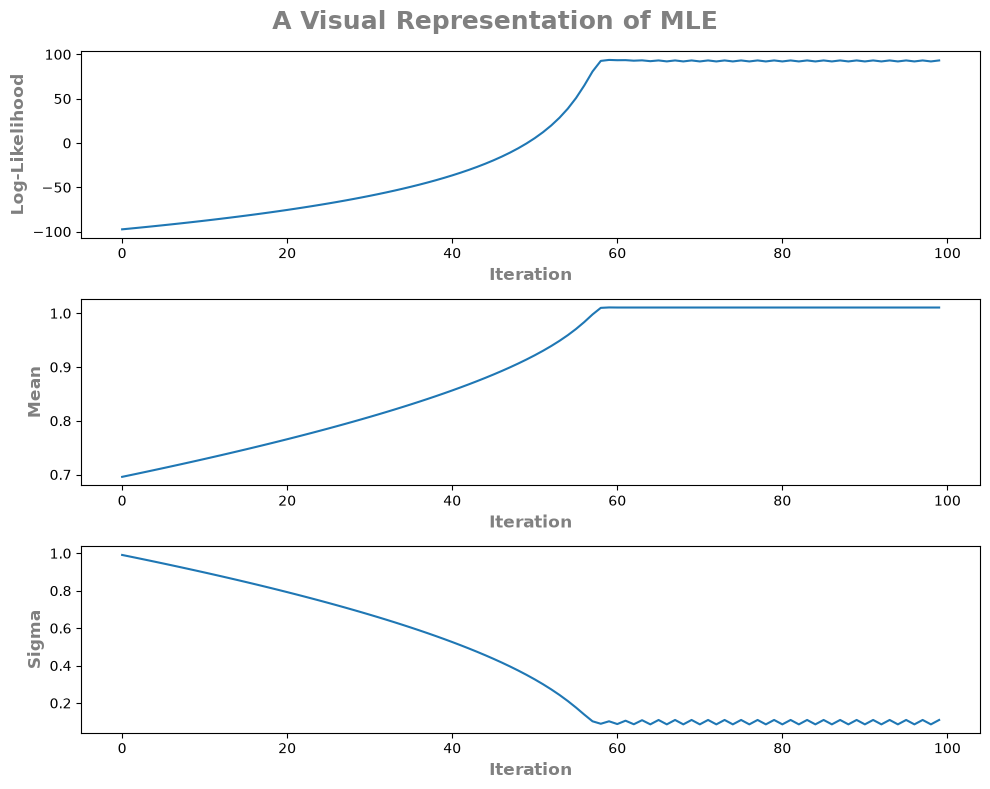

In [501]:
mu_,sig = gaussian_maximum_likelihood_function(normal_data)

print(mu_)
print(sig)

# AI Solution

In [416]:
"""AI Solution"""

import numpy as np


def log_likelihood_calculation(
    x: np.ndarray,
    mu: float,
    sigma: float
):
    """Calculate log-likelihood and its gradients."""

    n = len(x)

    # Log likelihood
    log_likelihood = (
        -n / 2 * np.log(2 * np.pi)
        -n * np.log(sigma)
        -np.sum((x - mu) ** 2) / (2 * sigma ** 2)
    )

    # dL/dmu
    mu_gradient = np.sum(x - mu) / sigma ** 2

    # dL/dsigma
    sigma_gradient = (
        -n / sigma
        + np.sum((x - mu) ** 2) / sigma ** 3
    )

    return log_likelihood, mu_gradient, sigma_gradient


def gaussian_mle(x: np.ndarray):

    # Starting values
    mu = np.min(x)
    sigma = 5.0

    iterations = 10000

    # Much smaller learning rate
    lr = 0.0001

    history = []

    for iteration in range(iterations):

        log_likelihood, mu_gradient, sigma_gradient = (
            log_likelihood_calculation(x, mu, sigma)
        )

        # Store values so we can inspect optimisation
        history.append(
            (iteration, mu, sigma, log_likelihood)
        )

        # Gradient ASCENT
        mu += lr * mu_gradient

        # Prevent sigma becoming zero/negative
        sigma += lr * sigma_gradient

        if sigma <= 0:
            raise ValueError("Sigma became non-positive")

        # Convergence
        if (
            abs(mu_gradient) < 1e-6
            and abs(sigma_gradient) < 1e-6
        ):
            break

    return mu, sigma, history




In [417]:
mu_,sig, sp = gaussian_mle(normal_data)

print(mu_)
print(sig)

1.0147451930340365
0.10815395848578534
